
🔬 SAVITZKY-GOLAY VISUALIZATION REPORT
⚙️ PARAMETERS SET:
   - Window Size: 51 (Must be Odd)
   - Poly Order:  6
   - Noise Level: 0.5
------------------------------------------------------------
📊 QUALITY METRICS (Comparison vs Ground Truth):
   1. Mean Squared Error (Lower is Better):
      - Raw Noisy:   0.00928
      - Filtered:    0.00136  (✅ Improved)
   2. Signal-to-Noise Ratio (Higher is Better):
      - Raw Noisy:   16.85 dB
      - Filtered:    25.18 dB (✅ Improved)


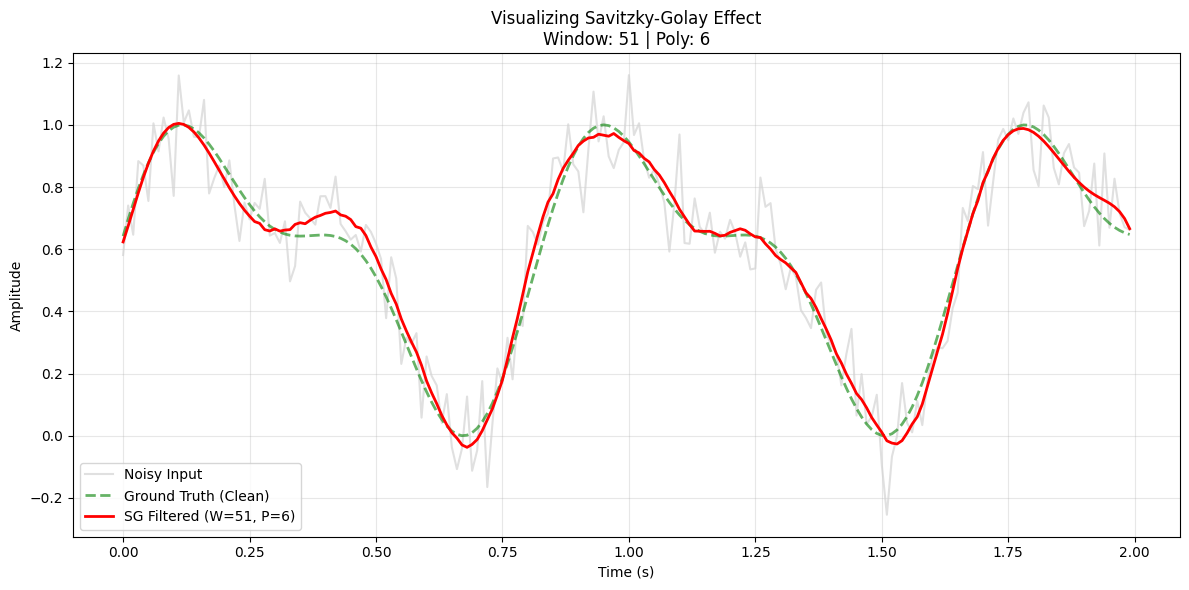

In [15]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ==========================================
# 🔧 MASTER CONFIGURATION (CHANGE THESE!)
# ==========================================
# 1. Savitzky-Golay Parameters
# Window Size: Must be ODD (e.g., 5, 11, 21, 51)
# - Small (5-11): Keeps sharp peaks, keeps some noise.
# - Large (31-51): Very smooth, might flatten peaks.
WINDOW_SIZE = 51  

# Poly Order: Polynomial Degree (e.g., 2 or 3)
# - Low (2): Smoother, simpler curve.
# - High (4-5): Follows complex wiggles (and noise) better.
POLY_ORDER = 6    

# 2. Simulation Settings
NOISE_LEVEL = 0.5  # Amplitude of random noise (0.1 = clean, 1.0 = very noisy)
FS = 100           # Sampling Frequency (Hz)
DURATION = 2       # Seconds

# ==========================================
# 🛠️ HELPER FUNCTIONS
# ==========================================
def generate_synthetic_ppg(fs, duration, noise_amp):
    """Generates a clean 'Shark Fin' signal and adds noise."""
    t = np.arange(0, duration, 1/fs)
    # Create a clean PPG-like shape (combining sines)
    clean_sig = 1.0 * np.sin(2 * np.pi * 1.2 * t) + 0.5 * np.sin(2 * np.pi * 2.4 * t + 0.5)
    # Normalize to 0-1
    clean_sig = (clean_sig - np.min(clean_sig)) / (np.max(clean_sig) - np.min(clean_sig))
    
    # Add Random Noise
    noise = np.random.normal(0, noise_amp * 0.2, len(t))
    noisy_sig = clean_sig + noise
    
    return t, clean_sig, noisy_sig

def calculate_quality_metrics(clean, noisy, filtered):
    """Calculates improvement stats."""
    # 1. MSE (Mean Squared Error) - How close to the Truth?
    mse_raw = mean_squared_error(clean, noisy)
    mse_filt = mean_squared_error(clean, filtered)
    
    # 2. SNR (Signal to Noise Ratio)
    # Power of Signal / Power of Error
    signal_power = np.sum(clean ** 2)
    noise_power_raw = np.sum((clean - noisy) ** 2)
    noise_power_filt = np.sum((clean - filtered) ** 2)
    
    if noise_power_raw == 0: snr_raw = 100
    else: snr_raw = 10 * np.log10(signal_power / noise_power_raw)
        
    if noise_power_filt == 0: snr_filt = 100
    else: snr_filt = 10 * np.log10(signal_power / noise_power_filt)
    
    return mse_raw, mse_filt, snr_raw, snr_filt

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================

# 1. Generate Data
t, clean_sig, noisy_sig = generate_synthetic_ppg(FS, DURATION, NOISE_LEVEL)

# 2. Apply Savitzky-Golay Filter
try:
    filtered_sig = signal.savgol_filter(noisy_sig, window_length=WINDOW_SIZE, polyorder=POLY_ORDER)
    status = "✅ Success"
except Exception as e:
    filtered_sig = np.zeros_like(noisy_sig)
    status = f"❌ Error: {e}"

# 3. Calculate Stats
mse_pre, mse_post, snr_pre, snr_post = calculate_quality_metrics(clean_sig, noisy_sig, filtered_sig)

# 4. Generate Report
print("\n" + "="*60)
print(f"🔬 SAVITZKY-GOLAY VISUALIZATION REPORT")
print("="*60)
print(f"⚙️ PARAMETERS SET:")
print(f"   - Window Size: {WINDOW_SIZE} (Must be Odd)")
print(f"   - Poly Order:  {POLY_ORDER}")
print(f"   - Noise Level: {NOISE_LEVEL}")
print("-" * 60)
print(f"📊 QUALITY METRICS (Comparison vs Ground Truth):")
print(f"   1. Mean Squared Error (Lower is Better):")
print(f"      - Raw Noisy:   {mse_pre:.5f}")
print(f"      - Filtered:    {mse_post:.5f}  ({'✅ Improved' if mse_post < mse_pre else '❌ Worsened'})")
print(f"   2. Signal-to-Noise Ratio (Higher is Better):")
print(f"      - Raw Noisy:   {snr_pre:.2f} dB")
print(f"      - Filtered:    {snr_post:.2f} dB ({'✅ Improved' if snr_post > snr_pre else '❌ Worsened'})")
print("="*60)
if "Error" in status:
    print(status)

# 5. Plot Comparison
plt.figure(figsize=(12, 6))

# Plot 1: Time Domain Comparison
plt.plot(t, noisy_sig, color='lightgray', label='Noisy Input', alpha=0.7)
plt.plot(t, clean_sig, color='green', linestyle='--', linewidth=2, label='Ground Truth (Clean)', alpha=0.6)
plt.plot(t, filtered_sig, color='red', linewidth=2, label=f'SG Filtered (W={WINDOW_SIZE}, P={POLY_ORDER})')

plt.title(f"Visualizing Savitzky-Golay Effect\nWindow: {WINDOW_SIZE} | Poly: {POLY_ORDER}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()